# Two Parks, Two Vacant Lots, and 1,254 Votes

In [1]:
import json, re
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import re

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, spearmanr

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#8a8983"
# darker variants for text so labels meet WCAG contrast on SURFACE
BLUETXT, REDTXT, GRAYTXT = "#1f62b4", "#c22a29", "#6e6d68"
SRC = "Source: Brooklyn Community Board 1 meeting minutes"
pd.set_option("display.max_colwidth", 200)
con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# full-text index: meeting_id -> complete minutes text (text layer + vision OCR)
_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
_sha2mid = {f["sha256"]: mid for mid, m in _meet.items() for f in m["files"]}
_texts = {}
for _tf in Path("../data/interim/text").glob("*.json"):
    _mid = _sha2mid.get(_tf.stem)
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + " ".join(json.loads(_tf.read_text()))
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _mid = _sha2mid.get(_of.name[:64])
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + _of.read_text()
_lower = {m: t.lower() for m, t in _texts.items()}
_dates = {m: v["date"] for m, v in _meet.items()}
lower = _lower
dates = _dates
def mentions(term):
    """Meetings where `term` appears, with counts. Case-insensitive."""
    term = term.lower()
    return pd.DataFrame(
        [(m, _dates[m], _lower[m].count(term)) for m in _lower if term in _lower[m]],
        columns=["meeting_id", "date", "n"],
    ).sort_values("date").reset_index(drop=True)

def context(term, meeting_id, width=200, k=5):
    """Verbatim passages around each occurrence of `term` in one meeting."""
    out = []
    for m in re.finditer(re.escape(term.lower()), _lower[meeting_id]):
        s = max(0, m.start() - width)
        out.append(" ".join(_texts[meeting_id][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

print(f"{len(_texts)} meetings indexed, {sum(len(t) for t in _texts.values())/1e6:.0f}M chars")
wf = pd.DataFrame(
    [(m, _meet[m]["date"], _lower[m].count("waterfront")) for m in _lower],
    columns=["meeting_id", "date", "wf_mentions"],
)
wf["date"] = pd.to_datetime(wf.date)
wf_meetings = wf[wf.wf_mentions > 0].sort_values("date").reset_index(drop=True)


110 meetings indexed, 31M chars


![Bushwick Inlet Park from the community center's green roof, April 2026: the soccer field in use on the left - and one of the two vacant lots on the right. Photo: author](images/bip_and_lots.jpg){fig-alt="View from a green roof: a full soccer field on the left and a flat, empty asphalt lot on the right, with the East River and Manhattan skyline behind."}


::: {.tldr}
**TLDR:** There are vacant waterfront lots in north Williamsburg that are both high value and underutilized. This area was rezoned to be a public park in 2005. I conducted a data study to learn how the community has shown up to voice frustration over this delay.
In 10 years of Community Board 1 meeting notes, the local advisory board for North Brooklyn, we can see that community turnout almost perfectly correlates with the way the board votes. Community outreach can lead to conditions attached to approvals.
:::



## The Backstory

There's a long backstory to the North Brooklyn waterfront. Over the last 20+ years this neighborhood has changed a lot. Williamsburg used to be home to local industry - my apartment building was a zipper factory. Currently Williamsburg is dominated by luxury condos and retail. The waterfront was owned by a combination of the city, state, and private owners. In 2005, then-Mayor Bloomberg made a deal to rezone the north Brooklyn waterfront. The plan allowed the building of luxury high-rise residential towers, increasing land value for private owners, and promised a waterfront park for the growing community. Since then, the waterfront high-rises have been built and continue to go up. Yet - we still only have a portion of the promised 28-acre park in Bushwick Inlet Park.

It's been two decades, where's our park?

![Navy airplanes over Greenpoint, May 1930. The piers, rail yards, and tank farms below are the land in focus for this article. Photo: [U.S. National Archives](https://commons.wikimedia.org/wiki/File:New_York_-_Brooklyn_-_NARA_-_68145045.jpg), public domain](images/aerial_1930_web.jpg){fig-alt="Black-and-white 1930 aerial photo of Navy biplanes flying over the Greenpoint waterfront's piers, rail yards, and tank farms."}

I was curious how the community can show up and make change happen. There are several community organizations focused on advocacy for different parts of the waterfront: Friends of Bushwick Inlet Park, North Brooklyn Neighbors, North Brooklyn Parks Alliance, Brooklyn Greenway Initiative, Newtown Creek Alliance, Friends of WNYC Transmitter Park. I wanted to get a sense of how these organizations play a role in pressuring government to develop this park. This land falls under Brooklyn Community Board 1 (CB1), the local advisory board for Williamsburg and Greenpoint. Every land use application has to come through it for a public hearing and a recommendation before the city decides.

## Scraping the minutes

CB1 posts its [meeting minutes online](https://www.nyc.gov/site/brooklyncb1/meetings/minutes.page). I created an automated script (code linked below) to scrape the PDFs and build a dataset of the key data points for these meetings.

The dataset covers all of CB1's 110 meetings, 1,254 votes, and 1,369 speakers. Most of the story below comes from the 97 meetings where the term 'waterfront' appears.

Each record is categorized by subject, which loosely mirrors the board's own committee structure: land use, liquor, parks, environment, transportation, budget. The minutes don't categorize votes, so I did it via LLM.

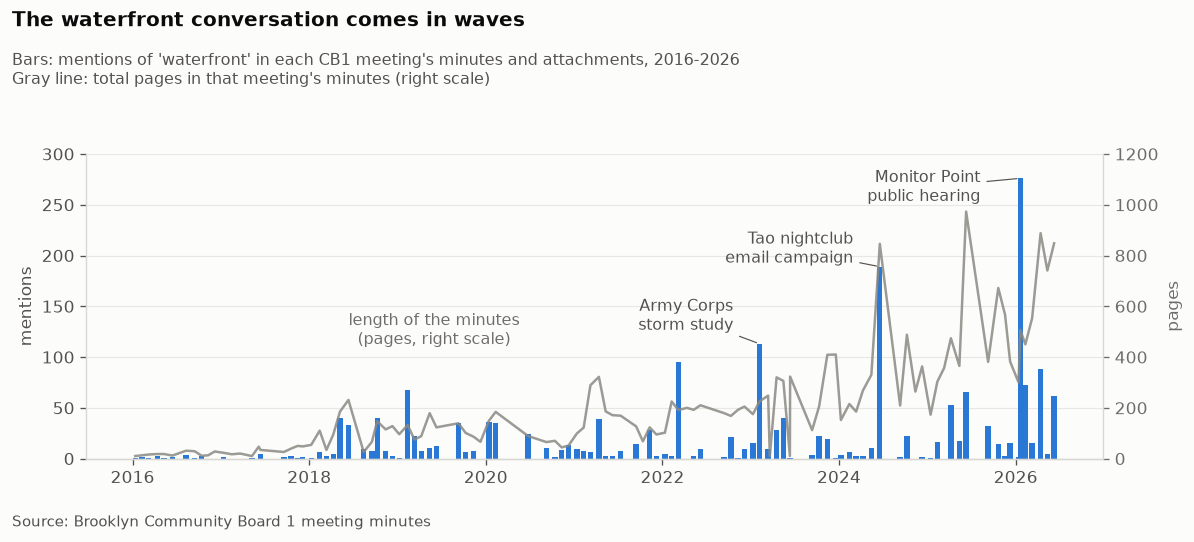

In [2]:
#| fig-alt: "Bar chart of waterfront mentions per CB1 meeting, 2016 to 2026. Mostly small bars with spikes labeled Army Corps storm study (113 mentions, 2023), Tao nightclub email campaign (189, 2024), and Monitor Point public hearing (276, 2026). A gray line on a right-hand scale shows each meeting's minutes growing from about 20 pages in 2016 to several hundred by 2026."
# pages per meeting: how thick the minutes themselves got over the decade
_pages = {}
for _mid, _m in _meet.items():
    _n = 0
    for _f in _m["files"]:
        _tp = Path(f"../data/interim/text/{_f['sha256']}.json")
        if _tp.exists():
            _n += len(json.loads(_tp.read_text()))
    _pages[_mid] = _n
wf["pages"] = wf.meeting_id.map(_pages)

fig, ax = plt.subplots(figsize=(10, 4.2), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.bar(wf_meetings.date, wf_meetings.wf_mentions, width=22, color=BLUE)
for d, v, label, off in [("2026-01-20", 276, "Monitor Point\npublic hearing", (-24, 6)),
                         ("2024-06-18", 189, "Tao nightclub\nemail campaign", (-16, 22)),
                         ("2023-02-07", 113, "Army Corps\nstorm study", (-16, 28))]:
    ax.annotate(label, (pd.Timestamp(d), v), xytext=off,
                textcoords="offset points", ha="right", va="top",
                fontsize=9.5, color=INK2,
                arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax.set_ylim(0, 300)
ax.set_ylabel("mentions", fontsize=10, color=INK2)
ax.tick_params(colors=INK2, labelsize=10)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#d8d7d2"); ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="y", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)

# right scale: the minutes' own length - the mentions' denominator in plain sight
axp = ax.twinx()
_ws = wf.sort_values("date")
axp.plot(_ws.date, _ws.pages, color=GRAY, lw=1.5, alpha=0.85)
axp.set_ylim(0, 1200)
axp.set_yticks(range(0, 1201, 200))
axp.set_ylabel("pages", fontsize=10, color=GRAYTXT)
axp.tick_params(colors=GRAYTXT, labelsize=10)
for s in ("top", "left"):
    axp.spines[s].set_visible(False)
axp.spines["right"].set_color("#d8d7d2")
axp.spines["bottom"].set_color("#d8d7d2")
axp.annotate("length of the minutes\n(pages, right scale)",
             (pd.Timestamp("2019-06-01"), 430), fontsize=9.5, color=GRAYTXT,
             ha="center", va="bottom")

fig.suptitle("The waterfront conversation comes in waves",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.90, "Bars: mentions of 'waterfront' in each CB1 meeting's minutes and attachments, 2016-2026\n"
         "Gray line: total pages in that meeting's minutes (right scale)",
         fontsize=9.5, color=INK2, va="top")
fig.text(0.01, -0.02, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

You can see that the term "waterfront" shows up frequently (the blue bars), with a few spikes in activity. These spikes get larger over time. It's important to also notice the gray line which shows that the length of the minutes themselves ballooned over the last decade. This is largely because the board office started binding testimony and correspondence into the record. We'll examine some of the actual text below to get a sense of what happens in these meeting notes:

January 20, 2026 — 276 mentions. This is a public hearing focused exclusively on Monitor Point. The notes are mostly written testimony from individuals and community groups including Veronica Zapasnik, a Polish immigrant who's been in the neighborhood since 1990, and NYSAFAH (the New York State Association for Affordable Housing). The opposition testimony repeats one claim: the rezoning of this land into a set of residential towers breaks a two-decade-old promise to make it a waterfront park for all.

June 18, 2024 — 189 mentions. There is a swarm of emails to the board about the proposal to open a Tao nightclub next to Bushwick Inlet Park, including one template that was re-sent over 100 times. The template focuses on the habitat restoration at the Inlet and the noise pollution a club would bring.

## Showing up - at the mic and in writing

Our dataset of CB1 meetings contains data points on the two main ways the community can voice their views: public speakers showing up to the board meetings and written testimony to the board. Public speakers are permitted at the board meetings after pre-approval for an allotment of 2-3 minutes. Alternatively, written testimony is accepted via email or letter. It only shows up in our dataset in volume in the last few years - more on that in the letters section below.

In [3]:
# mail parser (feeds the mail/room chart and the consistency guard): split
# each meeting's attachment pages into individual letters/emails, drop exact
# duplicates and the board's own outgoing letters, keyword-code each item's
# stance (see methodology).
MAIL_BOUND = re.compile(
    r"From: [A-Z][\w .’'-]{3,40}? Sent: |"
    r"Dear (?:Chair|Chairperson|Community Board|CB ?1|Members|Board|Mr\.|Ms\.|"
    r"Sir|Madam|District Manager)|To Whom It May Concern", re.I)
MAIL_AGAINST = re.compile(
    r"oppos|against|deny|denial|disapprov|reject|do not approve|vote no|say no|"
    r"no to |no more |stop (?:the|this)|not support|withdraw|concern|"
    r"urge.{0,60}(?:deny|vote no|no\b)", re.I)
MAIL_FOR = re.compile(
    r"\bsupport(?!er)|in favor|\bapprove|endorse|urge.{0,60}(?:approve|yes\b)|"
    r"vote yes|stand with", re.I)
# negated pro-phrases read as opposition ("cannot support", "not approve", ...)
MAIL_NEG = re.compile(
    r"(?:\bcannot|\bnot|n't|\bnever)\s+(?:support|approve|endorse)\w*", re.I)
# the board's own outgoing mail (SLA vote notices etc.) is not public opinion
MAIL_OUTGOING = re.compile(
    r"kindly be advised that at|"
    r"at the regular meeting of brooklyn community board no|"
    r"board voted to support sending this letter|"
    r"sincerely,? .{0,80}(?:chairperson|district manager)", re.I)

_mail_ocr = {}
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _sha, _p = _of.stem.rsplit("-p", 1)
    _mail_ocr.setdefault(_sha, []).append((int(_p), _of))

def _mail_items(mid):
    att = ""
    for f in _meet[mid]["files"]:
        sha = f["sha256"]
        sf = Path(f"../data/interim/segments/{sha}.json")
        if not sf.exists():
            continue
        body = set(json.loads(sf.read_text())["body_pages"])
        tp = Path(f"../data/interim/text/{sha}.json")
        pages = json.loads(tp.read_text()) if tp.exists() else []
        att += " ".join(p for i, p in enumerate(pages) if i not in body)
        for pno, of in _mail_ocr.get(sha, []):
            if pno not in body:
                att += " " + of.read_text()
    t = " ".join(att.split())
    # an email's own salutation is not a new item: drop the first Dear/To-Whom
    # boundary that falls inside the opening of a From:-header item
    idxs, last_from = [], None
    for b in MAIL_BOUND.finditer(t):
        is_from = b.group(0).lower().startswith("from:")
        if not is_from and last_from is not None and b.start() - last_from < 700:
            last_from = None
            continue
        last_from = b.start() if is_from else None
        idxs.append(b.start())
    return [t[st:min((idxs[j + 1] if j + 1 < len(idxs) else st + 1500), st + 2500)]
            for j, st in enumerate(idxs)]

def _mail_stance(txt):
    t = re.sub(r"[‘’“”\"']", "", txt)
    t = re.sub(r"to whom it may concern", " ", t, flags=re.I)
    t = MAIL_NEG.sub(" oppose ", t)
    a, f = len(MAIL_AGAINST.findall(t)), len(MAIL_FOR.findall(t))
    if a and f:  # both directions present: writers lead with their stance
        return ("against" if MAIL_AGAINST.search(t).start()
                < MAIL_FOR.search(t).start() else "for")
    return "against" if a > f else "for" if f > a else "unclear"

# every unique item bound into any meeting's minutes, coded once
_mid_by_date = {v: k for k, v in _dates.items()}
_rows, _seen = [], set()
for _mid in _meet:
    for _it in _mail_items(_mid):
        _k = re.sub(r"[^a-z0-9]", "", _it.lower())
        if _k in _seen:
            continue
        _seen.add(_k)
        _rows.append((_mid, _meet[_mid]["date"], _it,
                      bool(MAIL_OUTGOING.search(_it)), _mail_stance(_it)))
MAIL = pd.DataFrame(_rows, columns=["mid", "date", "text", "outgoing", "stance"])
INCOMING = MAIL[~MAIL.outgoing].reset_index(drop=True)

# a letter's subject lives in its header/opening; the window's tail can run
# into the next page's material, so match subjects on the first 1,200 chars
def _about(sub_df, pat):
    subj = re.compile(pat, re.I)
    return sub_df[sub_df.text.map(lambda t: bool(subj.search(t[:1200])))]



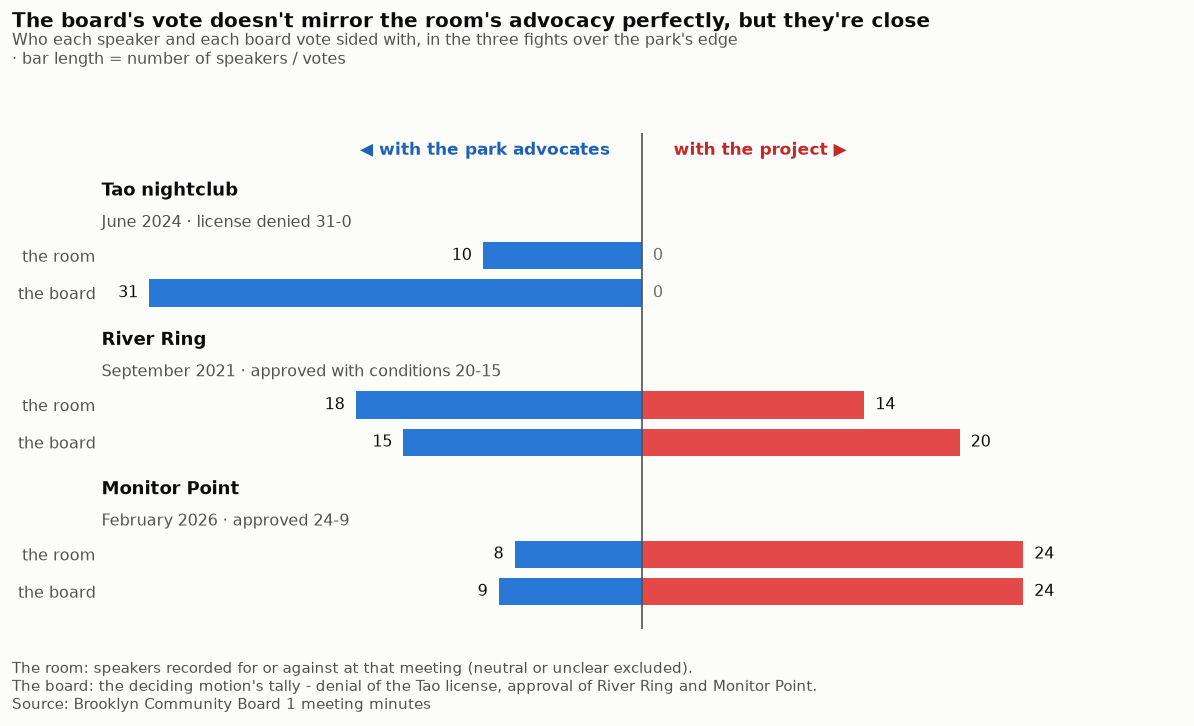

In [4]:
#| fig-alt: "Diverging bar chart of three fights: Tao nightclub, River Ring, and Monitor Point. For each, one row shows the room's speakers and one the board's votes, split between the park advocates' side and the project's side. The board sides with the room at Tao (10-0 room, 31-0 board) and Monitor Point (24-8 room for the project, 24-9 board); at River Ring an 18-14 room against faces a 20-15 board in favor."
# Three fights over the park's edge, from the park advocates' side.
# In each one the advocates opposed the project, so a speaker "against" and a
# board vote against approval both count as siding with the park. The deciding
# motion at Tao was a denial, so there the yes votes are the advocates' side.
def room(date, pat):
    d = q(f"""SELECT position, count(*) AS n
              FROM speakers s JOIN meetings m USING (meeting_id)
              WHERE m.date = '{date}' AND regexp_matches(lower(s.topic), '{pat}')
              GROUP BY 1""").set_index("position").n
    return int(d.get("against", 0)), int(d.get("for", 0))

def board(date, pat):
    v = q(f"""SELECT yes, no FROM votes v JOIN meetings m USING (meeting_id)
              WHERE m.date = '{date}'
                AND regexp_matches(lower(v.motion_text), '{pat}')""")
    assert len(v) == 1
    return int(v.iloc[0].yes), int(v.iloc[0].no)

deny_y, deny_n = board("2024-06-18", "deny the application for franklin")
rr_y, rr_n = board("2021-09-14", "yes with the committee.s conditions")
mp_y, mp_n = board("2026-02-10", "to approve application monitor point")

fights = [
    ("Tao nightclub", "June 2024 · license denied 31-0",
     room("2024-06-18", "franklin"), (deny_y, deny_n)),
    ("River Ring", "September 2021 · approved with conditions 20-15",
     room("2021-09-14", "river ring"), (rr_n, rr_y)),
    ("Monitor Point", "February 2026 · approved 24-9",
     room("2026-02-10", "monitor point"), (mp_n, mp_y)),
]

fig, ax = plt.subplots(figsize=(10, 5.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ys, ylabels = [], []
for g, (name, sub, (r_adv, r_proj), (b_adv, b_proj)) in enumerate(fights):
    y0 = g * 3.4
    ax.text(-34, y0 - 0.78, name, fontsize=11, color=INK, fontweight="bold",
            ha="left", va="center")
    ax.text(-34, y0 - 0.05, sub, fontsize=9.5, color=INK2, ha="left", va="center")
    for row, (adv, proj) in enumerate([(r_adv, r_proj), (b_adv, b_proj)]):
        y = y0 + 0.7 + row * 0.85
        ax.barh(y, -adv, height=0.62, color=BLUE)
        ax.barh(y, proj, height=0.62, color=RED)
        ax.annotate(str(adv), (-adv - 0.7, y), ha="right", va="center",
                    fontsize=9.5, color=INK if adv else GRAYTXT)
        ax.annotate(str(proj), (proj + 0.7, y), ha="left", va="center",
                    fontsize=9.5, color=INK if proj else GRAYTXT)
        ys.append(y)
        ylabels.append("the room" if row == 0 else "the board")

ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ys, ylabels, fontsize=9.5)
ax.set_ylim(9.2, -2.1)
ax.set_xlim(-34, 34)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(colors=INK2, length=0)
ax.annotate("◀ with the park advocates", (-2, -1.6), ha="right",
            fontsize=10, color=BLUETXT, fontweight="bold")
ax.annotate("with the project ▶", (2, -1.6), ha="left",
            fontsize=10, color=REDTXT, fontweight="bold")
fig.suptitle("The board's vote doesn't mirror the room's advocacy perfectly, but they're close",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.9, "Who each speaker and each board vote sided with, in the three fights over the park's edge\n"
         "· bar length = number of speakers / votes",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "The room: speakers recorded for or against at that meeting (neutral or unclear excluded).\n"
         "The board: the deciding motion's tally - denial of the Tao license, approval of River Ring and Monitor Point.\n"
         + SRC,
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

This chart zooms in on how the public speakers advocated and the board voted in three fights over the future of the park. Each fight gets two rows: who spoke at the hearing, and how the board voted.

The board's split tracks the room's split but not perfectly. The advocates' one win came when nobody showed up for the other side - ten speakers against the Tao nightclub and zero for it. The board denied the license 31-0. At Monitor Point the flow ran the other way: the project side filled the room 24 to 8, and the board landed at 24-9, almost the same ratio. River Ring is the only vote where the board varied from the room's position, but it was still close - an 18-14 room against, a 20-15 board in favor.

## What about the letters?

Speaking at the mic isn't the only way to reach the board - the meeting minutes bind letters and emails into the record. For example, the Tao nightclub motion drew nearly 200 emails. I coded each letter's stance to build the same view of who's on which side.

The minutes bind 1,015 letters and emails across the 110 meetings. 385 are the board's own outgoing mail, which I exclude from this analysis. The remaining 630 pieces of incoming correspondence mostly appear in the record after 2024 (84% land from 2024 on). So the four votes below are every vote with more than a single letter in the record. We do exclude a fifth: the Berry Street traffic study, which drew exactly one letter.

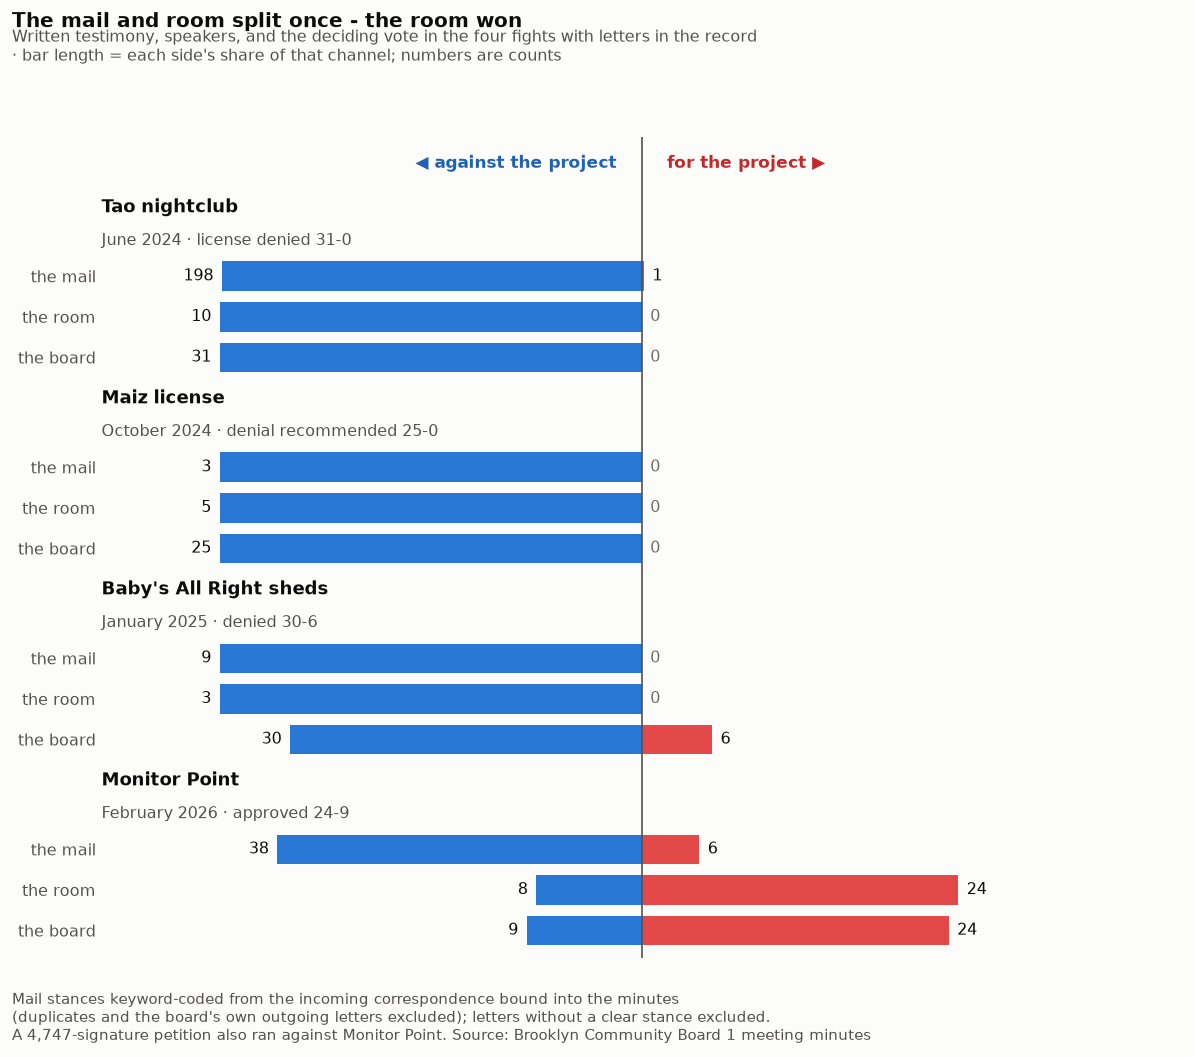

In [5]:
#| fig-alt: "Diverging bar chart of four fights: Tao nightclub, Maiz license, Baby's All Right sheds, and Monitor Point. Rows show the mail, the room, and the board split for and against each project. Mail runs against in all four (Tao 198-1, Maiz 3-0, sheds 9-0, Monitor Point 38-6); only at Monitor Point does the room run in favor (24-8), and the board lands 24-9 with the room."
# The mail, with direction: take the unique incoming items (parser above),
# match each to a fight by its header/opening, and use its keyword-coded
# stance. The stance rules were audited against the source text with an LLM
# review pass - every letter charted as 'for' below was read and confirmed;
# items whose stance the keywords can't call are excluded (see methodology).
def mail_counts(dates, pat):
    s = _about(INCOMING[INCOMING.date.isin(dates)], pat).stance.value_counts()
    return int(s.get("against", 0)), int(s.get("for", 0))

tao_y, tao_n = board("2024-06-18", "deny the application for franklin")
mz_y, mz_n = board("2024-10-08", "recommending the denial or revising")
ba_y, ba_n = board("2025-01-14", "outside shed")
# mp_y/mp_n (approve motion) already computed for the three-fights chart
mp_mail = mail_counts(["2026-01-20", "2026-02-10"], r"monitor point|40 quay|rezon")
tao_mail = mail_counts(["2024-06-18"], r"\btao\b|night ?club|11-25|franklin")
assert tao_mail[0] > 100 and mp_mail[0] > 3 * mp_mail[1], (tao_mail, mp_mail)

# (name, sub, mail(against,for), room(against,for), board(against,for))
# Maiz Corp's DBA is Tabu (from the motion text), so letters about Tabu count
MAIL_FIGHTS = [
    ("Tao nightclub", "June 2024 · license denied 31-0",
     tao_mail, room("2024-06-18", "franklin"), (tao_y, tao_n)),
    ("Maiz license", "October 2024 · denial recommended 25-0",
     mail_counts(["2024-10-08"], r"\bmaiz\b|\btabu\b|10 hope"),
     room("2024-10-08", "maiz|10 hope"), (mz_y, mz_n)),
    ("Baby's All Right sheds", "January 2025 · denied 30-6",
     mail_counts(["2025-01-14"], r"baby.s all right|deux chats|146 broadway|shed"),
     room("2025-01-14", "baby.s all right|146 broadway|outdoor dining"), (ba_y, ba_n)),
    ("Monitor Point", "February 2026 · approved 24-9",
     mp_mail, room("2026-02-10", "monitor point"), (mp_n, mp_y)),
]

fig, ax = plt.subplots(figsize=(10, 8.2), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ys, ylabels = [], []
for g, (name, sub, (m_ag, m_for), (r_ag, r_for), (b_ag, b_for)) in enumerate(MAIL_FIGHTS):
    y0 = g * 4.0
    ax.text(-1.28, y0 - 0.72, name, fontsize=11, color=INK, fontweight="bold",
            ha="left", va="center")
    ax.text(-1.28, y0 - 0.02, sub, fontsize=9.5, color=INK2, ha="left", va="center")
    for row, (ag, fr) in enumerate([(m_ag, m_for), (r_ag, r_for), (b_ag, b_for)]):
        y = y0 + 0.72 + row * 0.85
        tot = ag + fr
        ax.barh(y, -ag / tot, height=0.62, color=BLUE)
        ax.barh(y, fr / tot, height=0.62, color=RED)
        ax.annotate(str(ag), (-ag / tot - 0.02, y), ha="right", va="center",
                    fontsize=9.5, color=INK if ag else GRAYTXT)
        ax.annotate(str(fr), (fr / tot + 0.02, y), ha="left", va="center",
                    fontsize=9.5, color=INK if fr else GRAYTXT)
        ys.append(y)
        ylabels.append(("the mail", "the room", "the board")[row])
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ys, ylabels, fontsize=9.5)
ax.set_ylim(15.0, -2.2)
ax.set_xlim(-1.28, 1.28)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(colors=INK2, length=0)
ax.annotate("◀ against the project", (-0.06, -1.55), ha="right",
            fontsize=10, color=BLUETXT, fontweight="bold")
ax.annotate("for the project ▶", (0.06, -1.55), ha="left",
            fontsize=10, color=REDTXT, fontweight="bold")
fig.suptitle("The mail and room split once - the room won",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.925, "Written testimony, speakers, and the deciding vote in the four fights with letters in the record\n"
         "· bar length = each side's share of that channel; numbers are counts", fontsize=9.5, color=INK2, va="bottom")
fig.text(0.01, -0.015, "Mail stances keyword-coded from the incoming correspondence bound into the minutes\n"
         "(duplicates and the board's own outgoing letters excluded); letters without a clear stance excluded.\n"
         "A 4,747-signature petition also ran against Monitor Point. " + SRC,
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

For three of the four fights with mail in the record - Tao, the Maiz license, the Baby's All Right sheds - the letters, the mic, and the board all pointed the same way. 198 emails against the nightclub, versus exactly one in favor (subject line: "Tao night club, yes please!").

Monitor Point is the only fight where the channels split, and it answers the question of which is more important: mail or in-person advocacy. The mail ran six to one against the rezoning. A 4,747-signature petition opposed it. The room ran three to one in favor - union locals and the developer's own team filled the seats. The board went with the room, 24-9. When the mail and the mic disagreed, the board went with the bodies in the room.

One divergent case is thin evidence on its own. But it points the same way as everything else here: the board reflects the sentiment of the people speaking in the room.

## Does the room predict the vote?

These relationships are interesting, but not statistically rigorous. To draw a statistical conclusion we need more data points than the four fights with mail - so I drop the written testimony and use speakers alone. Below is the result of a regression predicting the board's vote based on the ratio of public speakers' advocacy for vs against a motion. Each of the 21 points in the graph below compares the proportion of the room in favor of a subject with the proportion of the board's votes in favor of it.

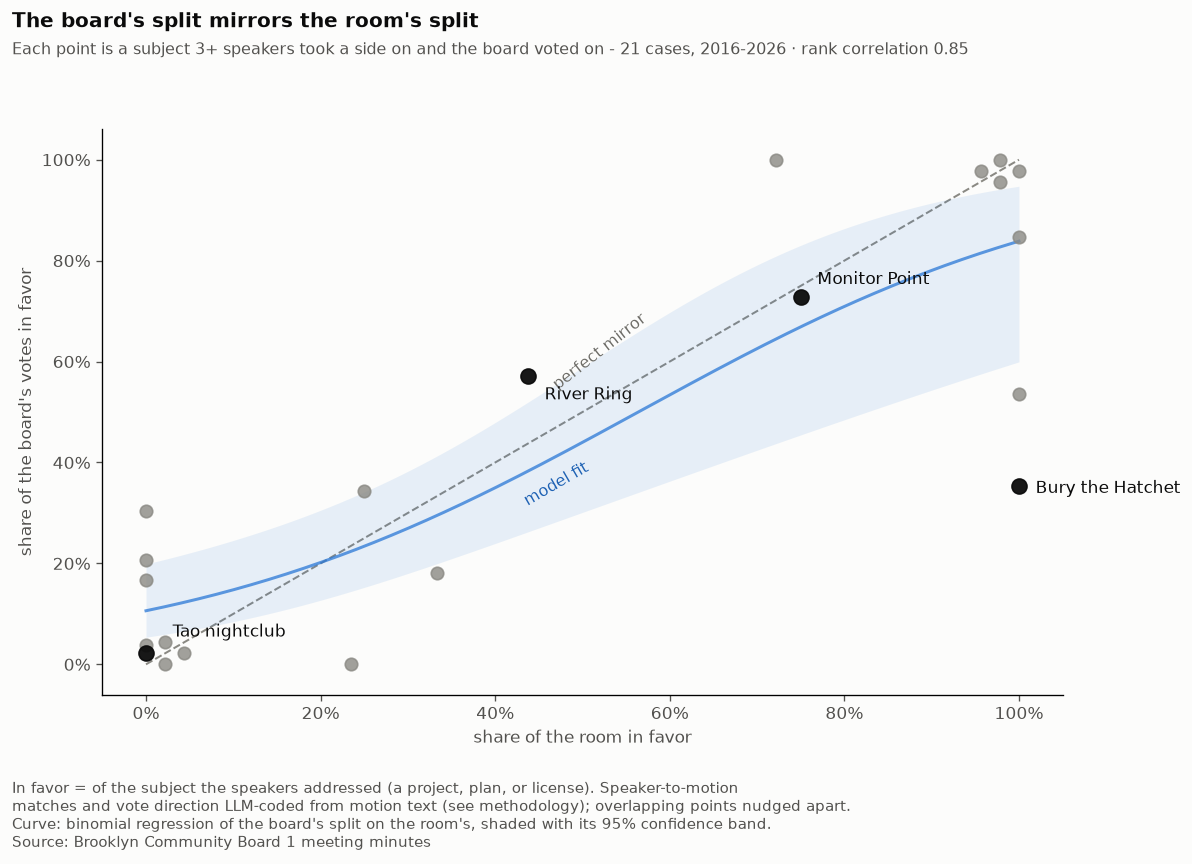

In [6]:
#| fig-alt: "Scatter plot of 21 subjects comparing the share of the room in favor against the share of the board's votes in favor. Points hug the diagonal; a regression curve with a 95 percent confidence band rises from about 11 percent board support when the room is unanimously against to 84 percent when unanimously in favor. River Ring and Bury the Hatchet sit off the line."
# Widen the net: every case where 3+ speakers took a side on a subject the
# board then voted on. The speaker-to-motion match and the motion's direction
# (does 'yes' side with the speakers' 'for'?) were coded by Claude Code from
# the motion text as part of the ETL; procedural motions and motions whose
# direction can't be recovered from the text are excluded.
# Columns: room for/against, board for/against.
MIRROR = pd.DataFrame([
    ("Metropolitan Ave bike lanes",    "2016-10-13",  3,  0, 34,  0),
    ("13-15 Greenpoint Ave amendment", "2017-01-10",  0,  7,  1, 25),
    ("Wburg Bridge access plan",       "2017-03-21",  5,  0, 29,  0),
    ("Transmitter Park concession",    "2017-05-09",  0,  4,  0, 31),
    ("Painting Lounge license",        "2017-11-14",  0,  4,  7, 16),
    ("Bury the Hatchet license",       "2018-12-11",  3,  0, 12, 22),
    ("10 Hope St license",             "2018-12-11",  1,  3, 11, 21),
    ("St. Paul's restoration",         "2019-01-08",  4,  0, 40,  0),
    ("Women's swim hours",             "2019-11-12",  4,  0, 22,  4),
    ("Meeker parking plan",            "2020-11-10",  0,  6,  0, 10),
    ("Meeker safety plan",             "2021-05-11", 13,  5, 14,  0),
    ("McGuinness redesign",            "2021-06-08", 24,  0,  8,  0),
    ("River Ring",                     "2021-09-14", 14, 18, 20, 15),
    ("BQE metered parking",            "2022-02-08",  1,  2,  2,  9),
    ("Monitor/Kingsland bike lanes",   "2022-06-07",  4, 13,  0, 29),
    ("Tao nightclub",                  "2024-06-18",  0, 10,  0, 31),
    ("Bedford Slip open street",       "2024-09-10",  0,  7,  6, 23),
    ("Maiz license",                   "2024-10-08",  0,  5,  0, 25),
    ("Baby's All Right sheds",         "2025-01-14",  0,  3,  6, 30),
    ("Monitor Point",                  "2026-02-10", 24,  8, 24,  9),
    ("Berry St traffic study",         "2026-06-09",  4,  0, 15, 13),
], columns=["label", "date", "rf", "ra", "bp", "ba"])
MIRROR["room"] = MIRROR.rf / (MIRROR.rf + MIRROR.ra)
MIRROR["board"] = MIRROR.bp / (MIRROR.bp + MIRROR.ba)

from scipy.stats import spearmanr
import statsmodels.api as sm
rho, _ = spearmanr(MIRROR.room, MIRROR.board)
mglm = sm.GLM(np.column_stack([MIRROR.bp, MIRROR.ba]),
              sm.add_constant(MIRROR.room),
              family=sm.families.Binomial()).fit(cov_type="HC1")

fig, ax = plt.subplots(figsize=(10, 6.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], ls="--", lw=1.2, color=GRAY, zorder=1)
ax.annotate("perfect mirror", (0.52, 0.545), fontsize=9.5, color=GRAYTXT,
            rotation=38, ha="center")
_xx = np.linspace(0, 1, 200)
_fit = mglm.get_prediction(sm.add_constant(_xx)).summary_frame()
ax.fill_between(_xx, _fit["mean_ci_lower"], _fit["mean_ci_upper"],
                color=BLUE, alpha=0.10, lw=0, zorder=1)
ax.plot(_xx, _fit["mean"], color=BLUE, lw=1.8, alpha=0.75, zorder=2)
ax.annotate("model fit", (0.47, 0.315), fontsize=9.5, color=BLUETXT,
            rotation=30, ha="center")

# nudge exactly-overlapping corner points apart so all 21 are visible;
# at the 0%/100% edges the ring is pulled inside so no dot leaves the domain
pts = MIRROR.copy()
for (x, y), g in pts.groupby(["room", "board"]):
    if len(g) > 1:
        cx = x - 0.022 * ((x > 0.99) - (x < 0.01))
        cy = y - 0.022 * ((y > 0.99) - (y < 0.01))
        for k, idx in enumerate(g.index):
            ang = 2 * np.pi * k / len(g)
            pts.loc[idx, "room"] = cx + 0.022 * np.cos(ang)
            pts.loc[idx, "board"] = cy + 0.022 * np.sin(ang)

named = {"Tao nightclub": (16, 10), "River Ring": (10, -14),
         "Monitor Point": (10, 8), "Bury the Hatchet license": (10, -4)}
for _, p in pts.iterrows():
    hot = p.label in named
    ax.plot(p.room, p.board, "o", ms=9 if hot else 7.5,
            color=INK if hot else GRAY, alpha=0.95 if hot else 0.8, zorder=3)
    if hot:
        dx, dy = named[p.label]
        ax.annotate(p.label.replace(" license", ""), (p.room, p.board),
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=10, color=INK)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.06, 1.06)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("share of the room in favor", fontsize=10, color=INK2)
ax.set_ylabel("share of the board's votes in favor", fontsize=10, color=INK2)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=INK2)
fig.suptitle("The board's split mirrors the room's split",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.925, f"Each point is a subject 3+ speakers took a side on and the board "
         f"voted on - {len(MIRROR)} cases, 2016-2026 · rank correlation {rho:.2f}",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "In favor = of the subject the speakers addressed (a project, plan, or license). Speaker-to-motion\n"
         "matches and vote direction LLM-coded from motion text (see methodology); overlapping points nudged apart.\n"
         "Curve: binomial regression of the board's split on the room's, shaded with its 95% confidence band.\n"
         + SRC,
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

The rank correlation is 0.85, and in 19 of 21 cases the board's majority landed on the same side as the room's majority. A regression on these points: a room unanimously against a project is associated with the board casting roughly one vote in ten for it. A room unanimously in favor, roughly five in six. With only 21 points those estimates come with a wide confidence band - that's the shading around the curve - so treat them as a direction, not a dial. The power to move a vote is not the absolute number of speakers but the balance of the room.

There are two outliers worth naming. River Ring is one - still, the vote wasn't far from the room's ratio. The other is Bury the Hatchet, an axe-throwing bar - three speakers came out for it, nobody against, and the board denied the license 22-12. The minutes explain the defiance: all three speakers were the applicant's own team, and the committee's support was conditional on a letter from the neighboring block association that never came. The board discounts a friendly room when the community isn't in it.

And all of this is correlation. We do not have enough data to show the counterfactual and we cannot prove that the speakers caused the vote to turn out a certain way.

In [7]:
# Prose-consistency guard: every number quoted in the text, recomputed.
# The render fails here if a re-extraction drifts the data out from under the prose.
assert len(MAIL) == 1015, len(MAIL)              # "1,015 letters and emails"
assert int(MAIL.outgoing.sum()) == 385           # "385 ... the board's own outgoing mail"
assert len(INCOMING) == 630, len(INCOMING)       # "630 pieces of incoming correspondence"
_p24 = (INCOMING.date >= "2024").mean()
assert abs(_p24 - 0.84) < 0.005, _p24            # "84% of it lands from 2024 on"
assert tao_mail == (198, 1), tao_mail            # "198 emails against ... one in favor"
assert mp_mail == (38, 6), mp_mail               # "six to one against"
assert len(_about(INCOMING[INCOMING.date == "2026-06-09"], "berry st")) == 1  # "exactly one letter"
assert len(MIRROR) == 21                         # "21 motions"
assert round(rho, 2) == 0.85                     # "rank correlation is 0.85"
assert ((MIRROR.room > 0.5) == (MIRROR.board > 0.5)).sum() == 19  # "19 of 21"
_e = mglm.predict(sm.add_constant(np.array([0.0, 1.0])))
assert 0.05 < _e[0] < 0.20 and 0.60 < _e[1] < 0.95  # "one in ten" / "five in six"
print("prose-consistency checks passed:",
      len(MAIL), len(INCOMING), f"{_p24:.1%}", tao_mail, mp_mail)

prose-consistency checks passed: 1015 630 84.3% (198, 1) (38, 6)


## So what role can the community play in developing this land into a park?

One outright win in ten years, and it was denying a nightclub, not building a park. But that undersells what community involvement is capable of. The community played a role in creating specific asks and conditions on these votes. Ten years of minutes point at one lever: the Land Use hearings. And volume of involvement alone doesn't move the needle - specific requests backed by the community do.

![One of the fenced-off lots at the park's edge, July 2026: cracked asphalt, weeds, and a skyline view going unused. Photo: author](images/lots_fence.jpg){fig-alt="A chain-link fence around a vacant lot of cracked asphalt and weeds, with the Manhattan skyline visible across the river."}

## Methodology

The dataset comes from the PDF meeting minutes CB1 posts publicly - 138 files covering 110 meetings from 2016 to 2026, about 22,000 pages. I extracted structured records (votes, liquor licenses, public speakers) with a custom ETL pipeline leveraging LLMs via AWS Bedrock to scan and extract data points. I hand-verified a subset of data points from three sample meetings against the original PDFs: vote tallies matched 38 of 38, license records 144 of 144, and speaker recall was 97%. Every extracted record keeps a verbatim quote from the source PDF, so any claim in this post can be traced back to a page. One extraction gap surfaced during this analysis - the September 2021 roll-call section, including the River Ring votes, had been misfiled as an attachment. I recovered it by hand from the minutes text, with the fix documented in the dataset.

Two disclaimers:

1. Everything stated above is association, not causation: big projects generate both turnout and division, and this data can't say which causes which. The mirror-chart regression comes with a wide confidence band at 21 points, and its speaker-to-motion matches were coded by Claude Code from the motion text as part of the ETL, not hand-verified.
2. Letters and emails are split out of the minutes' attachment pages by pattern matching, de-duplicated, and the board's own outgoing letters are excluded from all mail counts. Stances are keyword-coded with negation handling; when a letter argues both directions, the earlier match wins - writers lead with their stance. The coding rules were audited against the source letters with an LLM review pass, and every letter counted as "for" in the four fights was read and confirmed, but the full corpus is not human-verified. Letters without a clear keyword stance are excluded from the tallies. Correspondence is only bound into the minutes in volume from about 2024, so the written channel is mostly invisible before then.

The full pipeline, analysis notebooks, and the extracted dataset are on GitHub: [blowenstein0/cb1_data_analysis](https://github.com/blowenstein0/cb1_data_analysis).